In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('ford.csv')

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [7]:
df.shape

(17966, 9)

In [8]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(154)

<Axes: xlabel='price', ylabel='Count'>

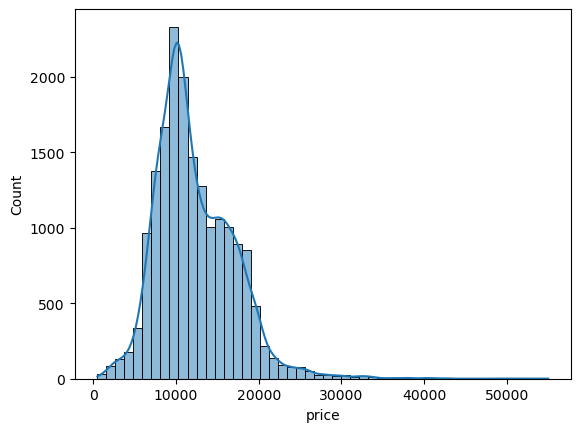

In [10]:
sns.histplot(data=df, x='price', bins=50, kde=True)

In [11]:
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000


<Axes: >

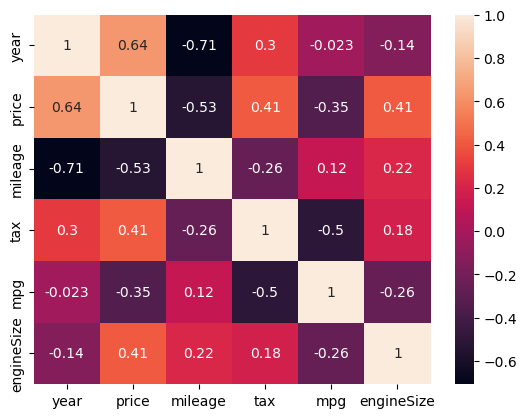

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [13]:
cat_feat = ['model', 'transmission', 'fuelType']
num_feat = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

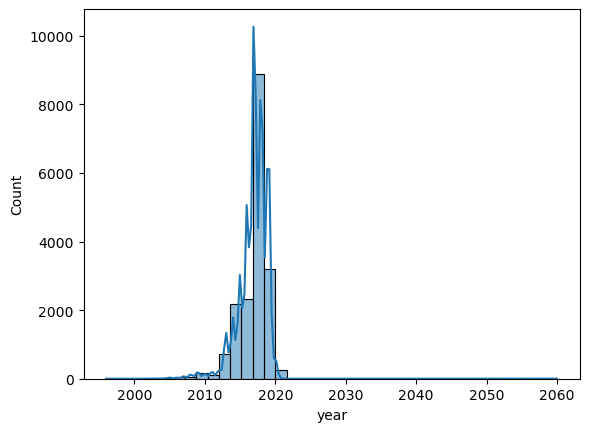

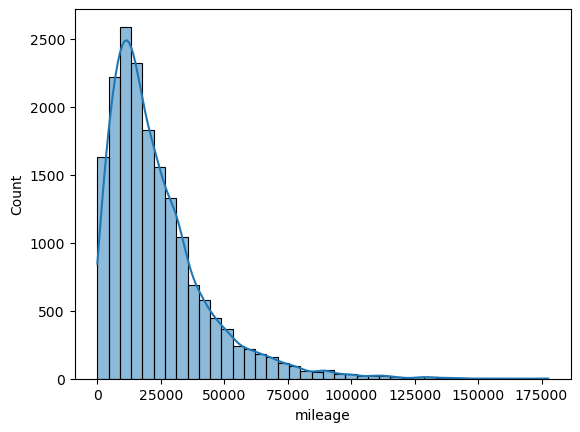

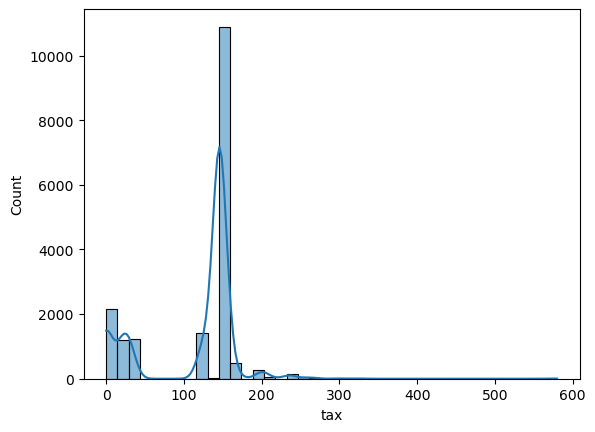

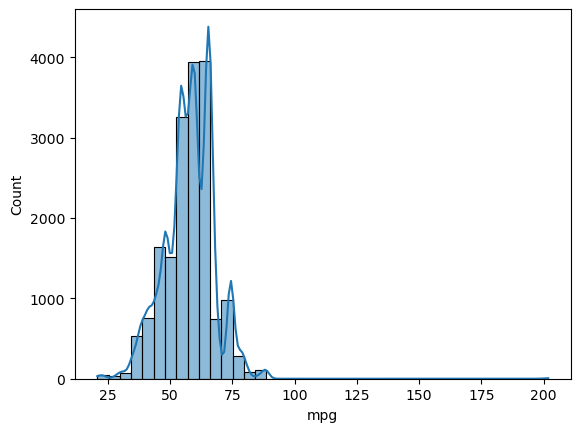

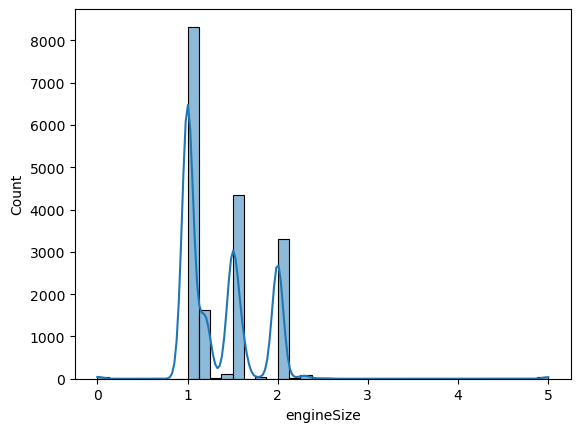

In [14]:
for feat in num_feat:
    sns.histplot(data=df, x=feat, bins=40, kde=True)
    plt.show()

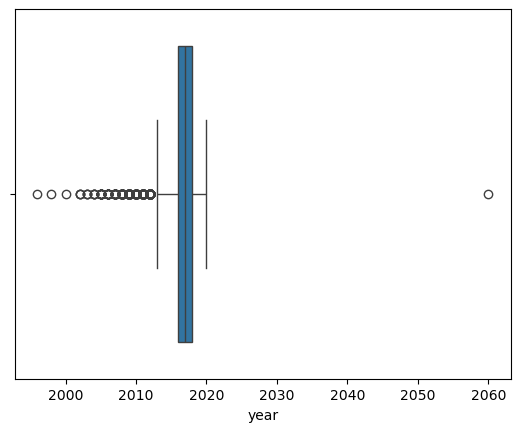

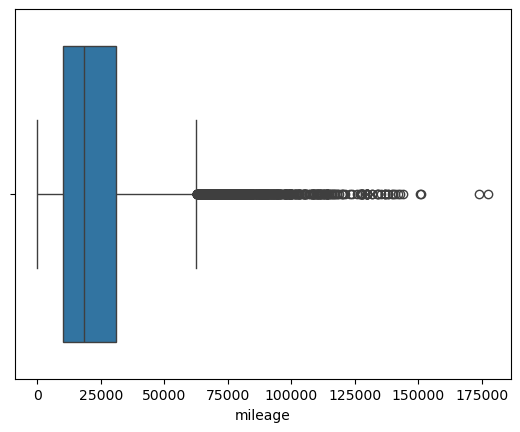

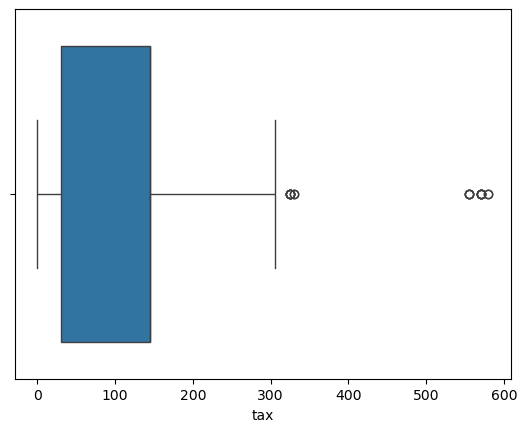

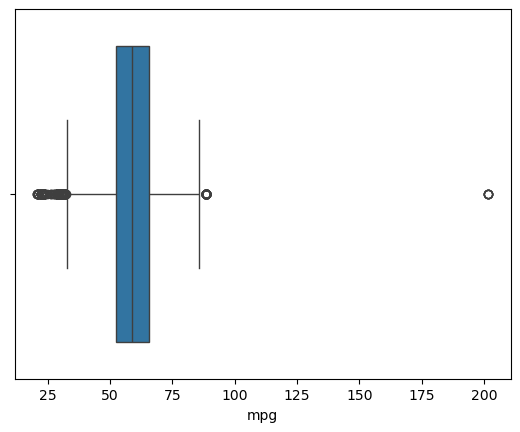

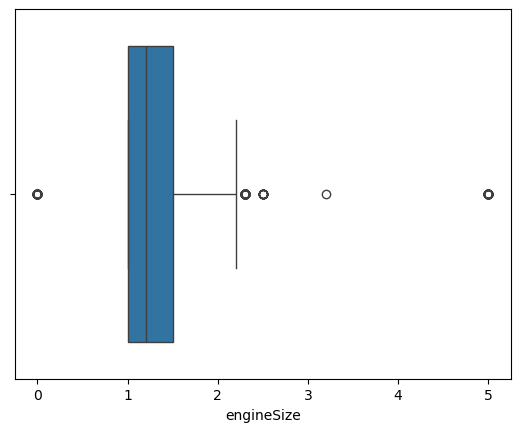

In [15]:
for feat in num_feat:
    sns.boxplot(data=df, x=feat)
    plt.show()

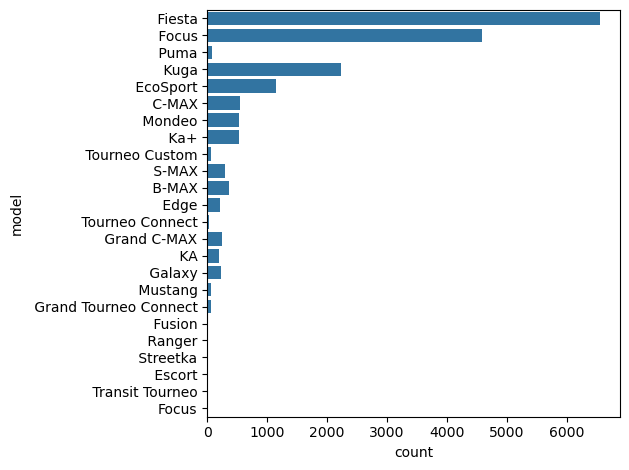

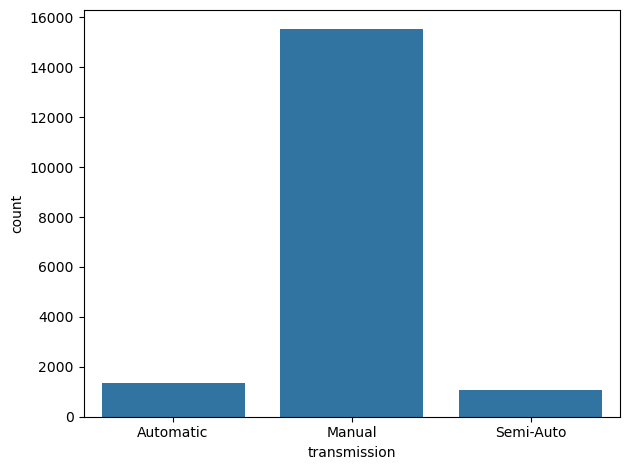

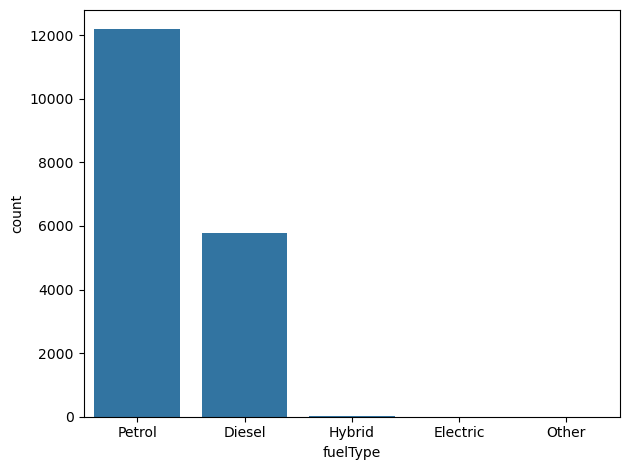

In [16]:
for feat in cat_feat:
    x = None if feat == 'model' else feat
    y = feat if feat == 'model' else None
    sns.countplot(data=df, x=x, y=y)
    plt.tight_layout()
    plt.show()

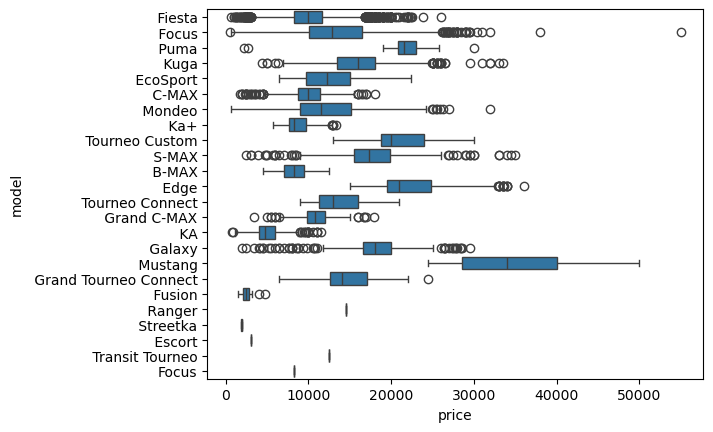

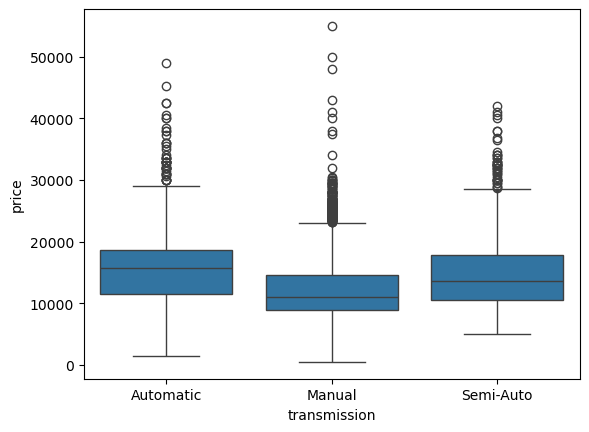

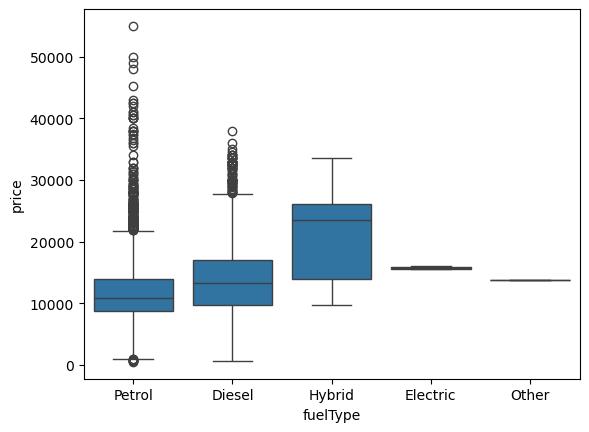

In [17]:
for feat in cat_feat:
    if feat == 'model':
        sns.boxplot(data=df, x='price', y=feat)
    else:
        sns.boxplot(data=df, x=feat, y='price')
    plt.show()

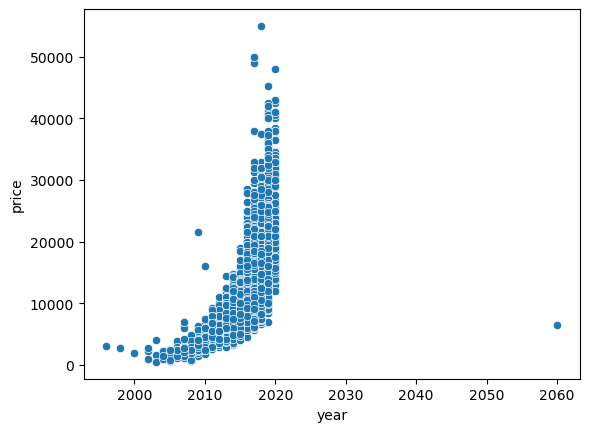

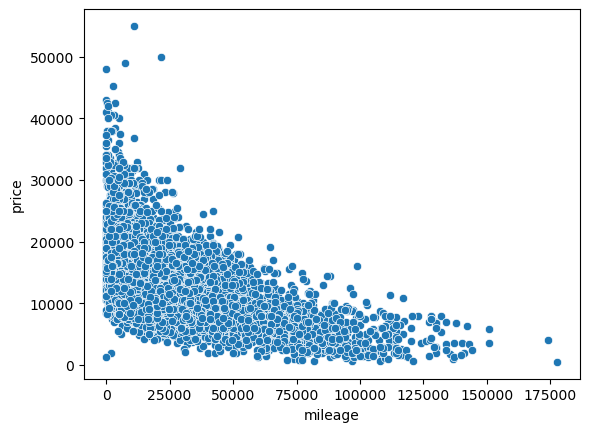

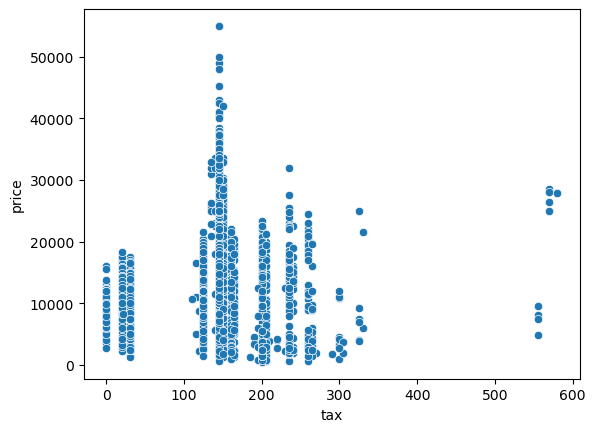

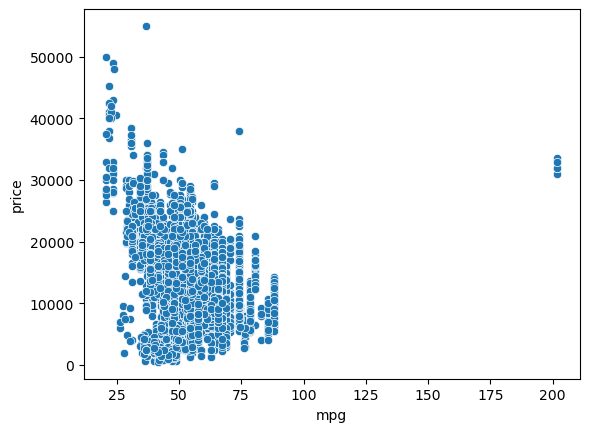

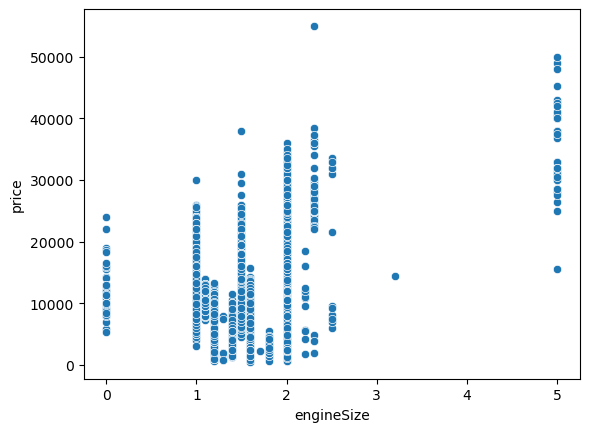

In [18]:
for feat in num_feat:
    sns.scatterplot(data=df, x=feat, y='price')
    plt.show()

In [19]:
df[df['year'] == 2060]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17726,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4


In [20]:
cp = pd.cut(df['year'], bins=10, labels=[x for x in range(10)])
type(cp)

pandas.core.series.Series

<Axes: xlabel='year', ylabel='price'>

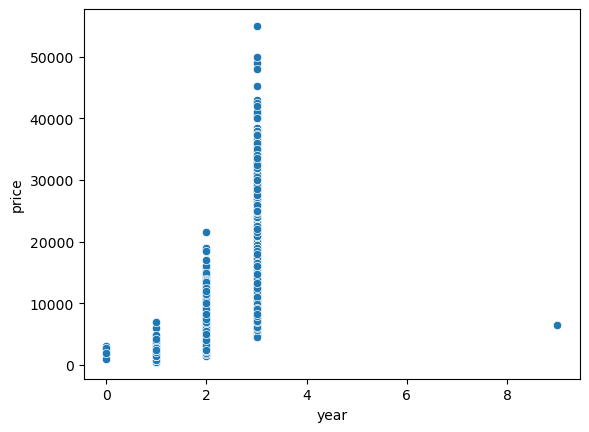

In [21]:
sns.scatterplot(x=cp, y=df['price'])

<Axes: xlabel='year', ylabel='price'>

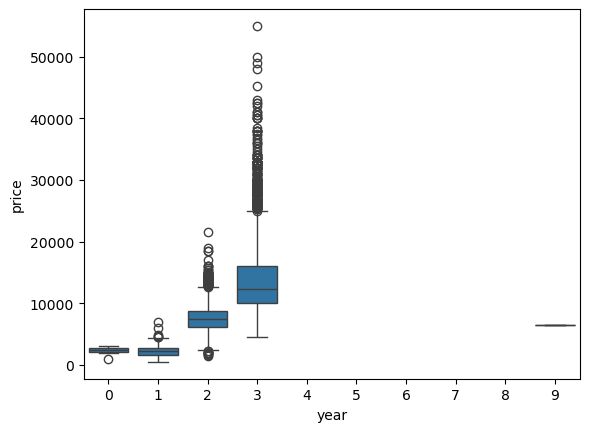

In [22]:
sns.boxplot(data=df, x=cp, y='price')

<Axes: xlabel='year', ylabel='price'>

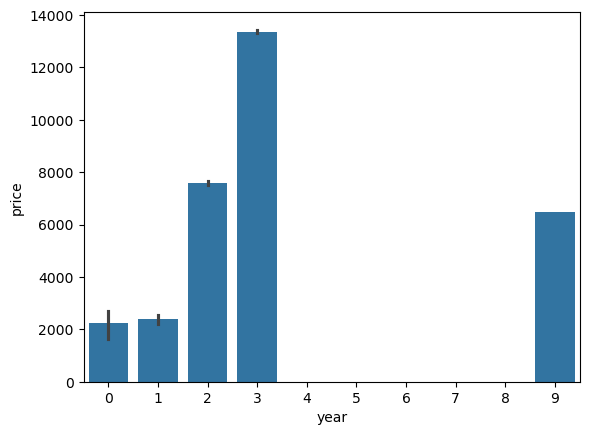

In [23]:
sns.barplot(data=df, x=cp, y='price')

<Axes: xlabel='price', ylabel='year'>

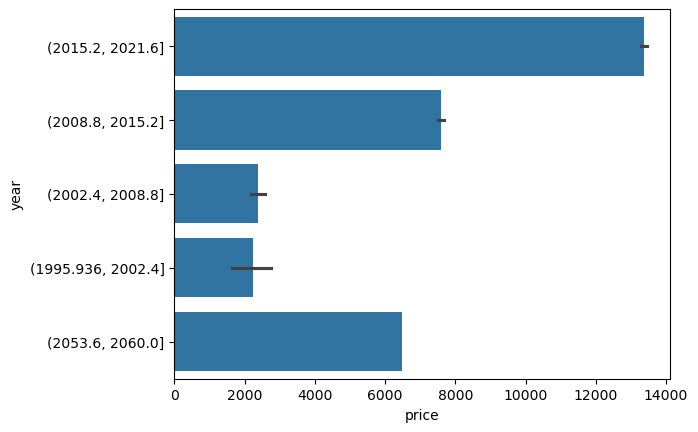

In [24]:
sns.barplot(y=pd.cut(df['year'], bins=10).astype(str), x=df['price'])

<Axes: xlabel='count', ylabel='year'>

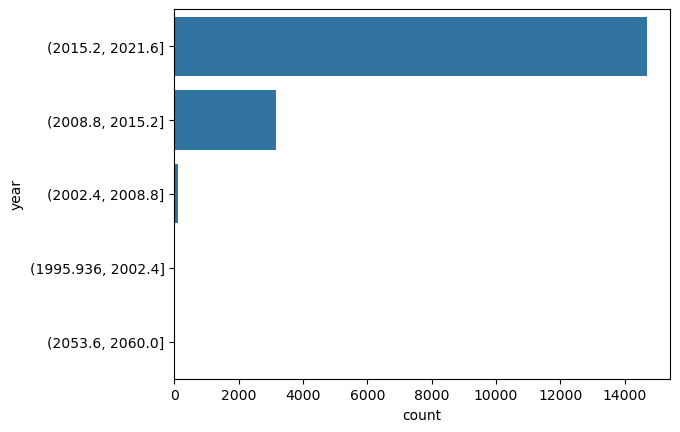

In [25]:
sns.countplot(y=pd.cut(df['year'], bins=10).astype(str))

In [26]:
pd.cut(df['year'], bins=10).astype(str).value_counts()

year
(2015.2, 2021.6]      14685
(2008.8, 2015.2]       3149
(2002.4, 2008.8]        125
(1995.936, 2002.4]        6
(2053.6, 2060.0]          1
Name: count, dtype: int64

In [27]:
cut_year = pd.cut(df['year'], bins=10).astype(str).reset_index().sort_values('year')['year']

<Axes: xlabel='count', ylabel='year'>

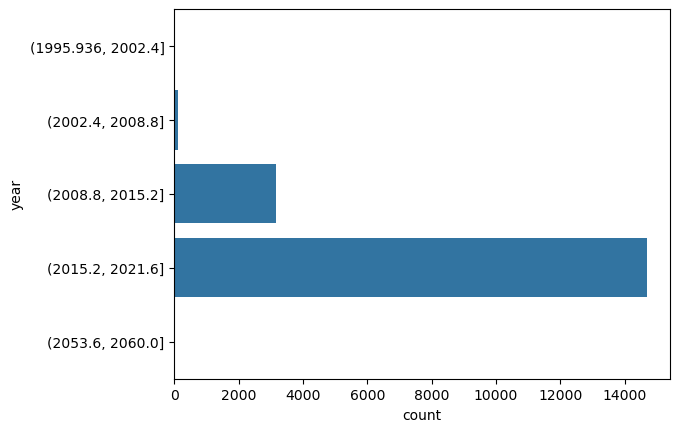

In [28]:
sns.countplot(y=cut_year)

<Axes: xlabel='tax', ylabel='price'>

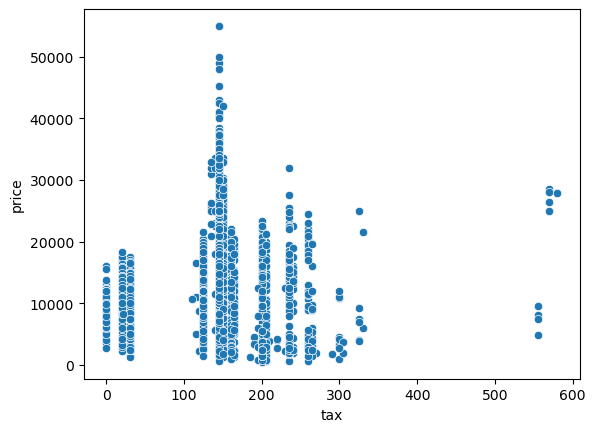

In [29]:
sns.scatterplot(x=df['tax'], y=df['price'])

<Axes: xlabel='mpg', ylabel='price'>

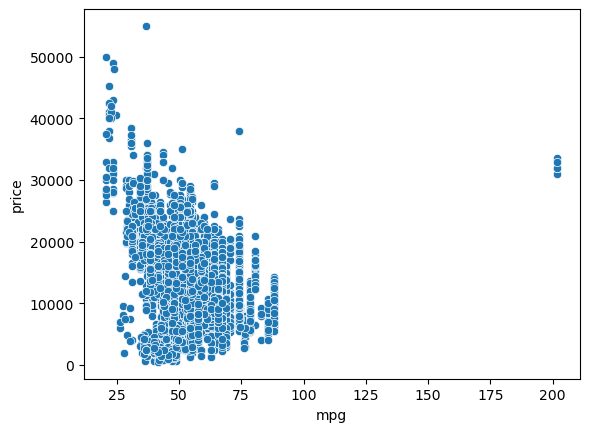

In [30]:
sns.scatterplot(x=df['mpg'], y=df['price'])

In [31]:
df.duplicated().sum()

np.int64(154)

In [32]:
df2 = df.drop_duplicates()

In [33]:
df[df.duplicated()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
159,Focus,2016,10995,Manual,30923,Diesel,0,74.3,1.5
312,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
349,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
510,EcoSport,2019,15489,Manual,5636,Diesel,145,68.9,1.5
512,Grand Tourneo Connect,2019,19999,Manual,3500,Diesel,145,61.4,1.5
...,...,...,...,...,...,...,...,...,...
14556,Mondeo,2015,6793,Manual,138000,Diesel,20,68.9,2.0
15121,Kuga,2017,14999,Manual,24877,Diesel,30,64.2,1.5
15127,EcoSport,2019,16799,Automatic,433,Petrol,150,45.6,1.0
15685,KA,2008,1795,Manual,63000,Petrol,160,45.6,1.3


In [34]:
df2.duplicated().sum()

np.int64(0)

In [35]:
X = df.drop('price', axis=1)

In [36]:
y = df['price']

In [37]:
df.drop(columns='price')

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [38]:
X_one_hot_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

In [39]:
X_one_hot_encoded.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='object')

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
X_label_encoded = X.copy()

In [42]:
encoders = {}

In [43]:
for col in ['model', 'transmission', 'fuelType']:
    le = LabelEncoder()
    X_label_encoded[col] = le.fit_transform(X_label_encoded[col])
    encoders[col] = le

In [44]:
encoders

{'model': LabelEncoder(),
 'transmission': LabelEncoder(),
 'fuelType': LabelEncoder()}

In [45]:
X_label_encoded

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler().set_output(transform='pandas')

In [48]:
X_one_hot_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [49]:
num_col = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

In [50]:
X_one_hot_encoded[num_col] = scaler.fit_transform(X_one_hot_encoded[num_col])

In [51]:
X_one_hot_encoded

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [52]:
X_label_encoded

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [53]:
X_label_encoded[X_label_encoded.columns] = scaler.fit_transform(X_label_encoded)

In [54]:
X_label_encoded

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [56]:
X_ohe_train, X_ohe_test, y_train, y_test = train_test_split(X_one_hot_encoded, y, test_size=0.2, random_state=42)

In [57]:
ohe_model = LinearRegression()

In [58]:
ohe_model.fit(X_ohe_train, y_train)

LinearRegression()

In [59]:
y_ohe_pred = ohe_model.predict(X_ohe_test)

In [60]:
r2_ohe = r2_score(y_test, y_ohe_pred)

In [61]:
r2_ohe

0.8458422267142565

In [62]:
adj_r2_ohe = 1 - (1 - r2_ohe) * ((X_ohe_test.shape[0] - 1) / (X_ohe_test.shape[0] - X_ohe_test.shape[1] - 1))

In [63]:
adj_r2_ohe

0.8443695196921392

In [64]:
X_le_train, X_le_test, y_train, y_test = train_test_split(X_label_encoded, y, test_size=0.2, random_state=42)

In [65]:
le_model = LinearRegression()

In [66]:
le_model.fit(X_le_train, y_train)

LinearRegression()

In [67]:
y_le_pred = le_model.predict(X_le_test)

In [68]:
r2_le = r2_score(y_test, y_le_pred)

In [69]:
r2_le

0.7365884288851352

In [70]:
adj_r2_le = 1 - (1 - r2_le) * ((X_le_test.shape[0] - 1) / (X_le_test.shape[0] - X_le_test.shape[1] - 1))

In [71]:
adj_r2_le

0.7360006206371801

In [72]:
from sklearn.linear_model import Ridge, Lasso

In [73]:
X_ohe_train, X_ohe_test, y_train, y_test = train_test_split(X_one_hot_encoded, y, test_size=0.2, random_state=42)

In [74]:
for alpha in [0.001, 0.01, 0.1, 0, 10]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_ohe_train, y_train)
    print(r2_score(y_test, ridge_model.predict(X_ohe_test)))

0.845842807427061
0.8458479711674471
0.8458941447474229
0.8458422267142565
0.8433625378118278


In [75]:
for alpha in [0.001, 0.01, 0.1, 0, 10]:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_ohe_train, y_train)
    print(r2_score(y_test, lasso_model.predict(X_ohe_test)))

0.8458430892695736
0.8458500360187393
0.8458603686109141
0.8458422267142564
0.8276652489937688


In [76]:
X_one_hot_encoded[X_one_hot_encoded['year'] == 2060]

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol


In [77]:
df_re = df[df['year'] != 2060]
df_re.duplicated().sum()
df_re = df_re.drop_duplicates()

In [78]:
df_re = pd.get_dummies(df_re, drop_first=True, dtype=int)

In [79]:
df.shape

(17966, 9)

In [80]:
df_re.shape

(17811, 35)

In [81]:
X_re = df_re.drop('price', axis=1)
y_re = df_re['price']

In [82]:
X_train_re, X_test_re, y_train, y_test = train_test_split(X_re, y_re, test_size=0.2, random_state=42)

In [83]:
# X_train_re = pd.get_dummies(X_train_re, drop_first=True, dtype=int)

In [84]:
model_re = LinearRegression()

In [85]:
model_re.fit(X_train_re, y_train)

LinearRegression()

In [86]:
# X_test_re = pd.get_dummies(X_test_re, drop_first=True, dtype=int)

In [87]:
y_pred_re = model_re.predict(X_test_re)

In [88]:
r2_re = r2_score(y_test, y_pred_re)

In [89]:
r2_re

0.8576924949169972